In [59]:
!pip install pandas pyreadstat
import pyreadstat


In [72]:
import pandas as pd

df = pd.read_csv('random_5k_rows.csv')
display(df.head())

,_AGE80,SEXVAR,INCOME3,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,ADDEPEV3,TOLDHI3
0,26.0,1.0,8.0,2.0,2.0,1.0,2584.0,2.0,2.0,2.0
1,46.0,1.0,11.0,3.0,5.0,1.0,3499.0,2.0,2.0,2.0
2,74.0,1.0,10.0,2.0,5.0,1.0,2481.0,2.0,1.0,2.0
3,55.0,1.0,10.0,1.0,3.0,1.0,2580.0,2.0,2.0,2.0
4,51.0,1.0,9.0,3.0,2.0,1.0,2953.0,2.0,2.0,2.0


# **Question 1**

## **1. Estimate**

### **Section A**

In [61]:
average_bmis = df.groupby('CVDINFR4')['_BMI5'].mean()
print("Average BMI by Heart Attack Status:")
print(average_bmis)

Average BMI by Heart Attack Status:
CVDINFR4
1.0    2992.912338
2.0    2943.407928
Name: _BMI5, dtype: float64


### **Section B**

In [62]:
import numpy as np
import scipy.stats as stats # Used to easily get the Z-value if not using 1.96

# Define the critical Z-value for a 95% CI
Z_CRITICAL = 1.96 # stats.norm.ppf(0.975)

# Calculate the grouped statistics
grouped_stats = df.groupby('CVDINFR4')['_BMI5'].agg(['mean', 'std', 'count'])

# --- Calculate the Confidence Interval ---
# 1. Calculate the Standard Error (SE)
grouped_stats['SE'] = grouped_stats['std'] / np.sqrt(grouped_stats['count'])

# 2. Calculate the Margin of Error (ME)
grouped_stats['ME'] = Z_CRITICAL * grouped_stats['SE']

# 3. Calculate the Lower and Upper Bounds of the CI
grouped_stats['CI_Lower'] = grouped_stats['mean'] - grouped_stats['ME']
grouped_stats['CI_Upper'] = grouped_stats['mean'] + grouped_stats['ME']

print("\n--- Confidence Interval Results (95% CI) ---")
print(grouped_stats[['count', 'CI_Lower', 'CI_Upper']])


--- Confidence Interval Results (95% CI) ---
          count     CI_Lower     CI_Upper
CVDINFR4                                 
1.0         308  2910.118781  3075.705894
2.0        4692  2921.990852  2964.825005


### **Section C**

From the Central Limit Theorem , with a large sample size ($n \approx 5,000$), the distribution of the sample mean ($\bar{X}_n$) is assumed to be approximately Normal.

Although the population variance ($\sigma^2$) is unknown, the sample variance ($\hat{\sigma}^2$) is a good estimator.

For large n, the $t$-distribution converges to the **Standard Normal ($Z$) distribution**, meaning their critical values ("chevrons") are nearly identical.

Therefore, we can accurately and practically use the **$Z$-score** for the confidence interval calculation based on the CLT.

Because the Confidence Intervals for the two categories overlap, we conclude there is insufficient strong evidence to claim that a statistically significant difference exists between the population mean BMI of individuals who have had a heart attack and those who have not.

## **2. Hypothesis tests**

### **Section A**

Null Hypothesis ($H_0$): The population means are equal. $$H_0: \mu_1 - \mu_2 = 0 $$

Alternative Hypothesis ($H_1$): The population means are not equal (two-tailed test). $$H_1: \mu_1 - \mu_2 \neq 0$$

### **Section B**

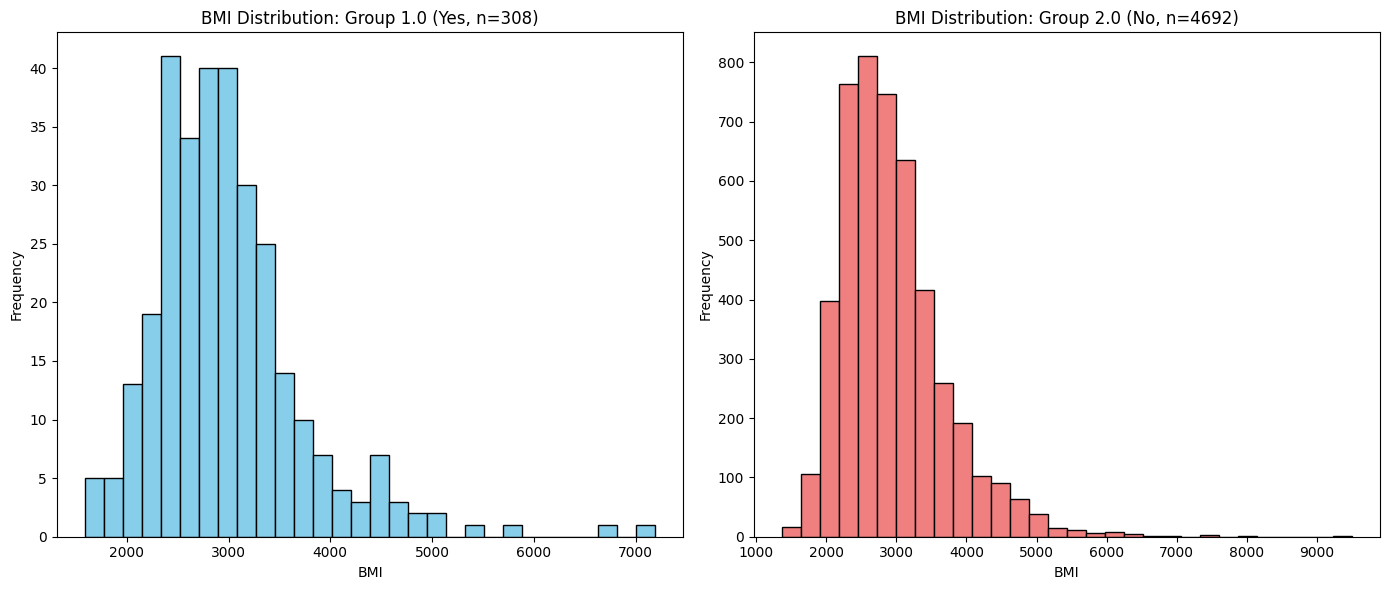

In [65]:
import matplotlib.pyplot as plt

group_yes = df[df['CVDINFR4'] == 1.0]['_BMI5' ]
group_no = df[df['CVDINFR4'] == 2.0]['_BMI5' ]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(group_yes, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title(f'BMI Distribution: Group 1.0 (Yes, n={len(group_yes)})')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Frequency')

axes[1].hist(group_no, bins=30, color='lightcoral', edgecolor='black')
axes[1].set_title(f'BMI Distribution: Group 2.0 (No, n={len(group_no)})')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [66]:
import numpy as np
from scipy import stats

S_series = df.groupby('CVDINFR4')['_BMI5'].agg('std')
N_series = df.groupby('CVDINFR4')['_BMI5'].agg('count')
X_bar_series = df.groupby('CVDINFR4')['_BMI5'].agg('mean')
alpha = 0.05

# --- 1. Define Variables from Grouped Statistics (S and N) ---
# S = df.groupby('CVDINFR4')['_BMI5'].agg('std')  # סטיית תקן
# N = df.groupby('CVDINFR4')['_BMI5'].agg('count') # גודל מדגם
alpha = 0.05

# Define the specific values based on the output table for clean calculation:
S1 = S_series.loc[1.0] # 741.337256
S2 = S_series.loc[2.0] # 748.485020
N1 = N_series.loc[1.0] # 308
N2 = N_series.loc[2.0] # 4692
X_bar1 =X_bar_series.loc[1.0]
X_bar2 =X_bar_series.loc[2.0]

df_num = N2 - 1
df_den = N1 - 1

# --- 2. Calculate F-Statistic ---
# F = S_larger^2 / S_smaller^2 (S2 is slightly larger)
F_statistic = (S2**2) / (S1**2)

# --- 3. Find Critical F-Value ---
# Since F = S_larger^2 / S_smaller^2, this is a ONE-TAILED test.
# The critical F-value is at the 1 - alpha level (0.95 for alpha=0.05).
critical_F = stats.f.ppf(1 - alpha, df_num, df_den)

# --- 4. Conclusion (Decision Rule: F > F_critical?) ---
# R.R.: F > F_(df_num, df_den), 1-alpha
print(f"F-Statistic (S2^2 / S1^2): {F_statistic:.4f}")
print(f"Critical F-Value (alpha={alpha}): {critical_F:.4f}")
print("-" * 50)

if F_statistic > critical_F:
    print("Conclusion: F-statistic > Critical F. REJECT H0.")
    print("Variances are assumed UNEQUAL (Use Welch's t-test).")
else:
    print("Conclusion: F-statistic <= Critical F." )
    print("FAIL TO REJECT H0.")
    print("Variances ARE assumed EQUAL.")

F-Statistic (S2^2 / S1^2): 1.0194
Critical F-Value (alpha=0.05): 1.1526
--------------------------------------------------
Conclusion: F-statistic <= Critical F.
FAIL TO REJECT H0.
Variances ARE assumed EQUAL.


The histograms show the data is **not normally distributed**, but the **Central Limit Theorem (CLT)** justifies the normality condition for the $t$-test.
In checking for equality of variances, the **$F$-test** showed the $F$-Statistic ($\approx 1.0194$) is less than the Critical Value ($\approx 1.1526$).
Therefore, we **failed to reject the null hypothesis**, and the variances are **assumed equal**, which allows us to use the **Pooled $t$-test**.

### **Section C - T Test**

In [67]:
# --- 1. Calculate Pooled Variance (S_p^2) ---
# Formula : S_p^2 = [ (n1-1)S1^2 + (n2-1)S2^2 ] / (n1 + n2 - 2)
numerator_sp2 = ((N1 - 1) * S1**2) + ((N2 - 1) * S2**2)
denominator_sp2 = N1 + N2 - 2
S_p2 = numerator_sp2 / denominator_sp2

# --- 2. Calculate T-Statistic ---
# Formula: t = (X_bar1 - X_bar2) / sqrt[ S_p^2 * (1/n1 + 1/n2) ]
mean_difference = X_bar1 - X_bar2
standard_error_pooled = np.sqrt(S_p2 * (1/N1 + 1/N2))

t_statistic = mean_difference / standard_error_pooled

# --- 3. Calculate P-value and Degrees of Freedom ---
df = N1 + N2 - 2  # Degrees of freedom
# We use ppf (Percent Point Function) at 1 - alpha/2 for the two-tailed critical value
t_critical = stats.t.ppf(1 - alpha/2, df)

print("--- Pooled T-Test Results (Critical Value Method) ---")
print(f"T-Statistic (calculated, |t|): {abs(t_statistic):.4f}")
print(f"Degrees of Freedom (df): {df}")
print(f"Critical T-Value (t_crit, alpha/2): {t_critical:.4f}")
print("-" * 50)

# --- 4. Conclusion (Decision based on t_critical < |t|) ---
# Reject H0 if |t_statistic| > t_critical
if abs(t_statistic) > t_critical:
    print("Decision: |t| > t_critical (1.1251 > 1.9600). REJECT H0.")
    print("Conclusion: There is a statistically significant difference.")
else:
    print("Decision: |t| <= t_critical (1.1251 <= 1.9600). FAIL TO REJECT H0.")
    print("Conclusion: There is NO statistically significant difference.")

--- Pooled T-Test Results (Critical Value Method) ---
T-Statistic (calculated, |t|): 1.1251
Degrees of Freedom (df): 4998
Critical T-Value (t_crit, alpha/2): 1.9604
--------------------------------------------------
Decision: |t| <= t_critical (1.1251 <= 1.9600). FAIL TO REJECT H0.
Conclusion: There is NO statistically significant difference.


The final result of the two-sample pooled $t$-test indicates there is **no statistically significant difference** in the population mean BMI between the heart attack and no heart attack groups. This conclusion is reached because the calculated **$t$-Statistic of $1.1251$** falls within the acceptance region, as it is **less than or equal to** the two-tailed **Critical $t$-Value of $1.9604$** (at $\alpha=0.05$ and $df=4998$), meaning we **fail to reject the null hypothesis** ($\mu_1 = \mu_2$). This result is consistent with the initial findings from the confidence intervals in Question 1, which showed significant overlap between the two group means.

### **Section D - Wald Test**



In [68]:
# --- PART D: Wald Test Results ---
print("\n--- Part D: Wald Test Results ---")
# The Wald statistic (W) is calculated exactly like the t-statistic but assumes known variance (asymptotic)
# and is compared to the Z-distribution (Standard Normal).
wald_statistic = t_statistic # Numerically identical in calculation
wald_critical = stats.norm.ppf(1 - alpha/2) # Critical Z-value (approx 1.96)

print(f"Wald Statistic (W): {wald_statistic:.4f}")
print(f"Critical Z-Value (alpha={alpha}): {wald_critical:.4f}")

if abs(wald_statistic) > wald_critical:
     print("Decision: |W| > Z_critical. REJECT H0.")
else:
     print("Decision: |W| <= Z_critical. FAIL TO REJECT H0.")


--- Part D: Wald Test Results ---
Wald Statistic (W): 1.1251
Critical Z-Value (alpha=0.05): 1.9600
Decision: |W| <= Z_critical. FAIL TO REJECT H0.


The Wald statistic did not exceed the critical value, so we fail to reject
$H_0$. The test therefore finds no significant difference between the two group means.

### **Section E - P Values Compare**

In [69]:
# t = observed T statistic
t = t_statistic   # or compute it yourself

# Two-sided Wald p-value:
t_p_value = 2 * stats.t.sf(abs(t), df)
print(f"T P-value: {t_p_value:.5f}")


# w = observed Wald statistic
w = wald_statistic   # or compute it yourself

# Two-sided Wald p-value:
wald_p_value = 2 * stats.norm.cdf(-abs(w))
print(f"Wald P-value: {wald_p_value:.5f}")


T P-value: 0.26061
Wald P-value: 0.26055


In both sections C and D we failed to reject $H_0$.
We also observe that the p-values from the t-test and the Wald test are essentially identical. This makes sense because both tests use the same test statistic, and with a large sample size the t-distribution is almost indistinguishable from the standard normal distribution. Therefore, both methods lead to the same conclusion.

### **Section D - Likelihood Ratio Test**

We assume that the data in both categories come from normal distributions with a **common but unknown variance**.

Denote $\{X_{1i}\}_{i=1}^{n_1}$ as the observations from category 1,

and $\{X_{2j}\}_{j=1}^{n_2}$ as the observations from category 2

Also denote $n = n_1 + n_2$




#### **Hypotheses**

We test whether the means of the two categories are equal:

$$
H_0 : \mu_1 - \mu_2 = 0
\qquad\text{vs.}\qquad
H_1 : \mu_1 - \mu_2 \ne 0.
$$




#### **Parameter Spaces**

Under the **alternative hypothesis** $H_1$, the parameters are unrestricted:
$$
\Theta = \{ (\mu_1, \mu_2, \sigma^2) : \mu_1, \mu_2 \in \mathbb{R},\ \sigma^2 > 0 \}.
$$
The dimension of this parameter space is
$$
r = \dim(\Theta) = 3.
$$

Under the **null hypothesis** $H_0$, the means are constrained to be equal:
$$
\mu_1 = \mu_2 = \mu
$$
so the parameter space becomes
$$
\Theta_0 = \{ (\mu, \sigma^2) : \mu \in \mathbb{R},\ \sigma^2 > 0 \}.
$$
The dimension of the restricted space is
$$
q = \dim(\Theta_0) = 2.
$$




#### **Likelihood Under the Alternative Hypothesis**

Assuming independence and normality with a common variance, the likelihood under $H_1$ is

$$
\mathcal{L}(\mu_1,\mu_2)
=
\frac{1}{(2\pi S_p^2)^{n/2}}
\prod_{i=1}^{n_1}
\exp\!\left(
-\frac{(X_{1i}-\mu_1)^2}{2S_p^2}
\right)
\prod_{j=1}^{n_2}
\exp\!\left(
-\frac{(X_{2j}-\mu_2)^2}{2S_p^2}
\right).
$$

The maximum likelihood estimators are
$$
\hat{\mu}_1 = \bar{X}_1,
\qquad
\hat{\mu}_2 = \bar{X}_2.
$$

Taking logarithms yields
$$
\log \mathcal{L}(\hat{\mu}_1,\hat{\mu}_2)
=
-\frac{n}{2}\log(2\pi S_p^2)
-
\frac{1}{2S_p^2}
\left(
SS_1 + SS_2
\right),
$$
where the **within-group sums of squares** are defined by

$$
SS_1 = \sum_{i=1}^{n_1} (X_{1i} - \bar{X}_1)^2,
\qquad
SS_2 = \sum_{j=1}^{n_2} (X_{2j} - \bar{X}_2)^2.
$$

Since the sample variances satisfy
$$
S_1^2 = \frac{1}{n_1-1} SS_1,
\qquad
S_2^2 = \frac{1}{n_2-1} SS_2,
$$
we may equivalently write
$$
SS_1 = (n_1-1)S_1^2,
\qquad
SS_2 = (n_2-1)S_2^2.
$$





#### **Likelihood Under the Null Hypothesis**

Under $H_0$, all observations share a common mean $\mu$.  
The MLE of the common mean is
$$
\hat{\mu} = \frac{n_1\bar{X}_1 + n_2\bar{X}_2}{n}.
$$

The likelihood under $H_0$ depends on the **total sum of squares**
$$
SS_{\text{total}} = \sum_{i=1}^{n} (X_i - \hat{\mu})^2.
$$

This quantity admits the exact decomposition
$$
SS_{\text{total}}
=
SS_1 + SS_2
+ n_1(\bar{X}_1 - \hat{\mu})^2
+ n_2(\bar{X}_2 - \hat{\mu})^2.
$$

The first two terms measure **within-group variability**, while the last two terms measure **between-group variability**.  
This decomposition follows from the identity
$$
X_{1i}-\hat{\mu} = (X_{1i}-\bar{X}_1) + (\bar{X}_1-\hat{\mu}),
$$
together with the fact that
$$
\sum_{i=1}^{n_1}(X_{1i}-\bar{X}_1)=0,
$$
and similarly for group 2.

The variance estimator under $H_0$ is
$$
\hat{\sigma}^2 = \frac{SS_{\text{total}}}{n-1}.
$$

The log-likelihood under $H_0$ is therefore
$$
\log \mathcal{L}(\hat{\mu})
=
-\frac{n}{2}\log(2\pi \hat{\sigma}^2)
-
\frac{SS_{\text{total}}}{2\hat{\sigma}^2}.
$$




#### **Likelihood Ratio Statistic**

So for conclusion, the likelihood ratio statistic is defined as
$$
\lambda
=
2\left[
\log \mathcal{L}(\hat{\theta})
-
\log \mathcal{L}(\hat{\theta}_0)
\right],
$$
where $\hat{\theta}$ and $\hat{\theta}_0$ are the MLEs under $H_1$ and $H_0$, respectively.



In [70]:
from scipy.stats import chi2

# --- Likelihood Ratio Test for H0: μ1 - μ2 = 0 ---

n1, n2 = N1, N2
n = n1 + n2

# 1. Within-group sums of squares around each group mean
#    ss_g = (n_g - 1) * s_g^2  because std in pandas uses ddof=1
ss1 = (n1 - 1) * (S1 ** 2)
ss2 = (n2 - 1) * (S2 ** 2)

# 2. Log-likelihood under H1 (unrestricted): different means, common variance S_p2
#    L(μ̂1, μ̂2) = [1 / sqrt(2π S_p²)]^n * exp( - [Σ(x1-μ̂1)² + Σ(x2-μ̂2)²] / (2 S_p²) )
#    log L = - n/2 * log(2π S_p²) - (ss1 + ss2) / (2 S_p²)
logL_H1 = - (n / 2) * np.log(2 * np.pi * S_p2) - (ss1 + ss2) / (2 * S_p2)

# 3. Log-likelihood under H0: μ1 = μ2 = μ, variance = sample variance of all data

# overall mean μ̂
mu_hat = (n1 * X_bar1 + n2 * X_bar2) / n

# total sum of squares around the global mean:
# Σ(x-μ̂)² = ss1 + ss2 + n1(μ1-μ̂)² + n2(μ2-μ̂)²
ss_total = (
    ss1
    + ss2
    + n1 * (X_bar1 - mu_hat) ** 2
    + n2 * (X_bar2 - mu_hat) ** 2
)

# sample variance of all observations together (ddof = 1)
sigma2_hat = ss_total / (n - 1)

# log L(μ̂) = - n/2 * log(2π σ̂²) - Σ(x-μ̂)² / (2 σ̂²)
logL_H0 = - (n / 2) * np.log(2 * np.pi * sigma2_hat) - ss_total / (2 * sigma2_hat)

# 4. Likelihood ratio statistic and decision
lambda_stat = 2 * (logL_H1 - logL_H0)   # λ = 2[log L(θ̂) − log L(θ̂0)]
r = 3                                   # dim(θ1)
q = 2                                   # dim(θ0)
df_lr = r - q                           # dim(θ) − dim(θ0) = 3 − 2 = 1

chi2_crit = chi2.ppf(1 - alpha, df_lr)
p_value_lr = 1 - chi2.cdf(lambda_stat, df_lr)

print("--- Likelihood Ratio Test (Section 2f) ---")
print(f"Lambda statistic (λ): {lambda_stat:.4f}")
print(f"Chi-square critical value (df=1, α={alpha}): {chi2_crit:.4f}")
print(f"p-value (LRT): {p_value_lr:.4f}")

if lambda_stat > chi2_crit:
    print("Decision: λ > χ²_crit → REJECT H0 → μ1 != μ2.")
else:
    print("Decision: λ ≤ χ²_crit → FAIL TO REJECT H0 → μ1 = μ2.")


--- Likelihood Ratio Test (Section 2f) ---
Lambda statistic (λ): 1.2659
Chi-square critical value (df=1, α=0.05): 3.8415
p-value (LRT): 0.2605
Decision: λ ≤ χ²_crit → FAIL TO REJECT H0 → μ1 = μ2.


#### **Conclusion**

The likelihood ratio statistic was $ \lambda = 1.2659 $, which is smaller than the critical value $ \chi^2_{1,0.95} = 3.8415 $.  
The corresponding p-value was $ p = 0.2605 > 0.05 $.
So, from these reasons, we **fail to reject** $H_0 : \mu_1 = \mu_2$.

Therefore, the likelihood ratio test provides **no evidence of a statistically significant difference** between the two group means.


# **Question 3**

### **Sections A + B**

In [73]:
Z_CRITICAL = stats.norm.ppf(1 - alpha/2)  # 1.96 for 95%

sizes = [30, 50, 100, 500]

def ci_by_group(dataframe, group_col='CVDINFR4', x_col='_BMI5', z=Z_CRITICAL):
    g = dataframe.groupby(group_col)[x_col].agg(['mean', 'std', 'count']).copy()
    g['SE'] = g['std'] / np.sqrt(g['count'])
    g['ME'] = z * g['SE']
    g['CI_Lower'] = g['mean'] - g['ME']
    g['CI_Upper'] = g['mean'] + g['ME']
    return g[['count', 'CI_Lower', 'CI_Upper']]

# 1) Create 4 sampled DataFrames
samples = {n: df.sample(n=n, replace=False, random_state=42) for n in sizes}

# 2) Compute CI tables for each sample
ci_tables = {n: ci_by_group(samples[n]) for n in sizes}

# Print results
for n in sizes:
    print(f"\n--- 95% CI Results for Random Sample n={n} ---")
    print(ci_tables[n])



--- 95% CI Results for Random Sample n=30 ---
          count     CI_Lower     CI_Upper
CVDINFR4                                 
1.0           6  2493.459784  2960.540216
2.0          24  2516.135278  3028.281388

--- 95% CI Results for Random Sample n=50 ---
          count     CI_Lower     CI_Upper
CVDINFR4                                 
1.0           6  2493.459784  2960.540216
2.0          44  2657.623982  3007.330563

--- 95% CI Results for Random Sample n=100 ---
          count     CI_Lower     CI_Upper
CVDINFR4                                 
1.0          12  2518.124258  2844.209076
2.0          88  2761.628473  3063.871527

--- 95% CI Results for Random Sample n=500 ---
          count     CI_Lower     CI_Upper
CVDINFR4                                 
1.0          41  2672.695333  3056.963204
2.0         459  2880.423663  3019.637339


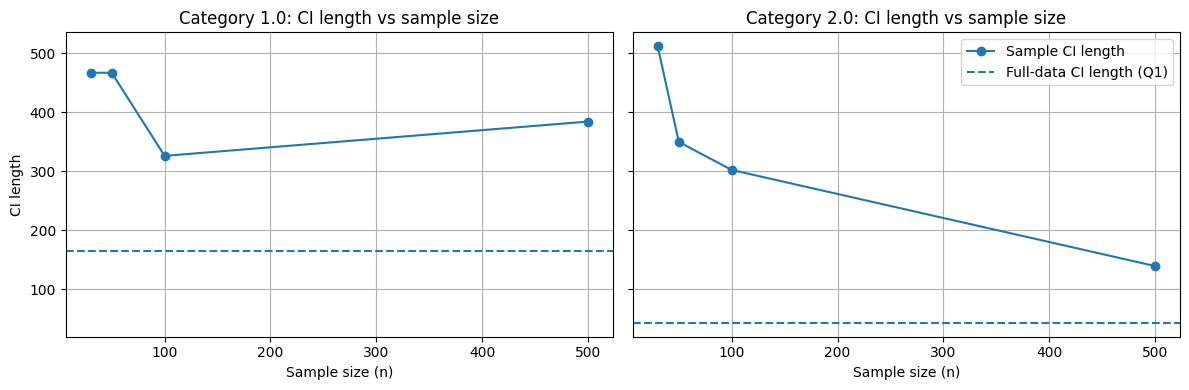

In [74]:
cats = [1.0, 2.0]   # Categories

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, cat in zip(axes, cats):
    # CI lengths from samples (section 3b)
    sample_ci_lengths = [
        ci_tables[n].loc[cat, 'CI_Upper'] - ci_tables[n].loc[cat, 'CI_Lower']
        for n in sizes
    ]

    # CI length from full data (question 1)
    full_ci_length = grouped_stats.loc[cat, 'CI_Upper'] - grouped_stats.loc[cat, 'CI_Lower']

    ax.plot(sizes, sample_ci_lengths, marker='o', label='Sample CI length')
    ax.axhline(full_ci_length, linestyle='--', label='Full-data CI length (Q1)')

    ax.set_title(f"Category {cat}: CI length vs sample size")
    ax.set_xlabel("Sample size (n)")
    ax.grid(True)

axes[0].set_ylabel("CI length")
axes[1].legend()

plt.tight_layout()
plt.show()


From the comparison of confidence interval lengths across different sample sizes, we observe a clear decreasing trend in Category 2: as the sample size increases, the confidence interval becomes shorter and converges toward the interval obtained from the full dataset. In Category 1, this monotonic behavior is less pronounced, which can be attributed to random sampling variability, especially for smaller sample sizes. Overall, the results support our theoretical expectation that increasing the sample size reduces estimation variance, leading to narrower confidence intervals and convergence toward the true mean.


### **Section C**

In [88]:
wald_results = []

for n in sizes:
    samp = df.sample(n=n, replace=False, random_state=None)

    g1 = samp.loc[samp['CVDINFR4'] == 1.0, '_BMI5']
    g2 = samp.loc[samp['CVDINFR4'] == 2.0, '_BMI5']

    X_bar1, X_bar2 = g1.mean(), g2.mean()
    S1, S2 = g1.std(ddof=1), g2.std(ddof=1)
    N1, N2 = len(g1), len(g2)

    # pooled variance
    Sp2 = ((N1 - 1)*S1**2 + (N2 - 1)*S2**2) / (N1 + N2 - 2)

    # standard error
    SE = np.sqrt(Sp2 * (1/N1 + 1/N2))

    # Wald statistic
    W = (X_bar1 - X_bar2) / SE

    # two-sided p-value
    p_value = 2 * stats.norm.sf(abs(W))

    decision = "Reject H0" if abs(W) > Z_CRITICAL else "Fail to reject H0"

    wald_results.append({
        "Sample size": n,
        "Wald statistic": W,
        "p-value": p_value,
        "Decision": decision
    })

wald_df = pd.DataFrame(wald_results)
wald_df


,Sample size,Wald statistic,p-value,Decision
0,30,3.218898,0.001287,Reject H0
1,50,0.815720,0.414661,Fail to reject H0
2,100,-0.443378,0.657492,Fail to reject H0
3,500,-0.564312,0.572542,Fail to reject H0


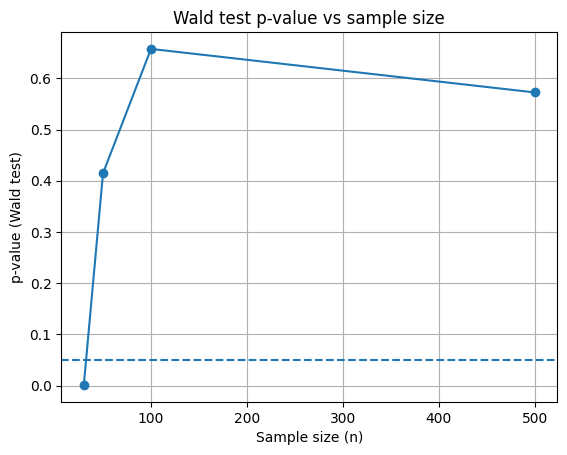

In [89]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(wald_df["Sample size"], wald_df["p-value"], marker='o')
plt.axhline(alpha, linestyle='--')
plt.xlabel("Sample size (n)")
plt.ylabel("p-value (Wald test)")
plt.title("Wald test p-value vs sample size")
plt.grid(True)
plt.show()


For small samples, the results are unstable and the p-values may behave inconsistently. This occurs because small samples are less representative of the population and exhibit higher variability, so random differences between the sample means may lead to rejection of the null hypothesis.

As the sample size increases, the variability of the estimators decreases and the sample means converge to their true values. Consequently, the p-values become more stable and better reflect the presence or absence of a true difference between the groups.

In our case, rejection of the null hypothesis occurred only for a small and non-representative sample (n = 30), while for larger samples — and in particular for the full dataset — we failed to reject the null hypothesis. This suggests that increasing the sample size leads to more reliable conclusions and reduces the risk of incorrect rejection of the null hypothesis.


### **Section D**

In [95]:
R = 100

results = []

# true means from Question 1 (full data)
true_means = grouped_stats['mean']

for n in sizes:
    for _ in range(R):
        samp = df.sample(n=n, replace=False)

        g1 = samp.loc[samp['CVDINFR4'] == 1.0, '_BMI5'].dropna()
        g2 = samp.loc[samp['CVDINFR4'] == 2.0, '_BMI5'].dropna()

        if len(g1) < 2 or len(g2) < 2:
            continue

        # --- CI for each group ---
        def ci_info(x):
            xbar = x.mean()
            s = x.std(ddof=1)
            n = len(x)
            se = s / np.sqrt(n)
            lo = xbar - Z_CRITICAL * se
            hi = xbar + Z_CRITICAL * se
            return lo, hi, hi - lo

        lo1, hi1, len1 = ci_info(g1)
        lo2, hi2, len2 = ci_info(g2)

        cover1 = lo1 <= true_means.loc[1.0] <= hi1
        cover2 = lo2 <= true_means.loc[2.0] <= hi2

        # --- Wald test ---
        xbar1, xbar2 = g1.mean(), g2.mean()
        s1, s2 = g1.std(ddof=1), g2.std(ddof=1)
        n1, n2 = len(g1), len(g2)

        Sp2 = ((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2)
        SE = np.sqrt(Sp2 * (1/n1 + 1/n2))
        W = (xbar1 - xbar2) / SE
        p_value = 2 * stats.norm.sf(abs(W))

        results.append({
            "n": n,
            "CI_length_cat1": len1,
            "CI_length_cat2": len2,
            "p_value": p_value,
            "cover_cat1": cover1,
            "cover_cat2": cover2
        })

res_df = pd.DataFrame(results)


/tmp/ipython-input-118541857.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sizes)


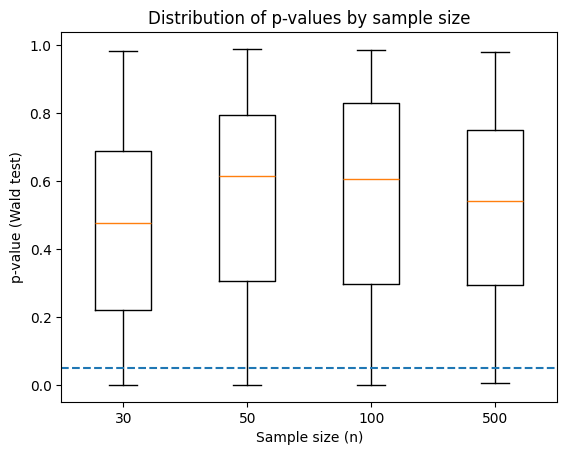

In [96]:
plt.figure()
data = [res_df.loc[res_df['n'] == n, 'p_value'] for n in sizes]
plt.boxplot(data, labels=sizes)
plt.axhline(alpha, linestyle='--')
plt.xlabel("Sample size (n)")
plt.ylabel("p-value (Wald test)")
plt.title("Distribution of p-values by sample size")
plt.show()


/tmp/ipython-input-1086940286.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_cat1, labels=sizes)
/tmp/ipython-input-1086940286.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_cat2, labels=sizes)


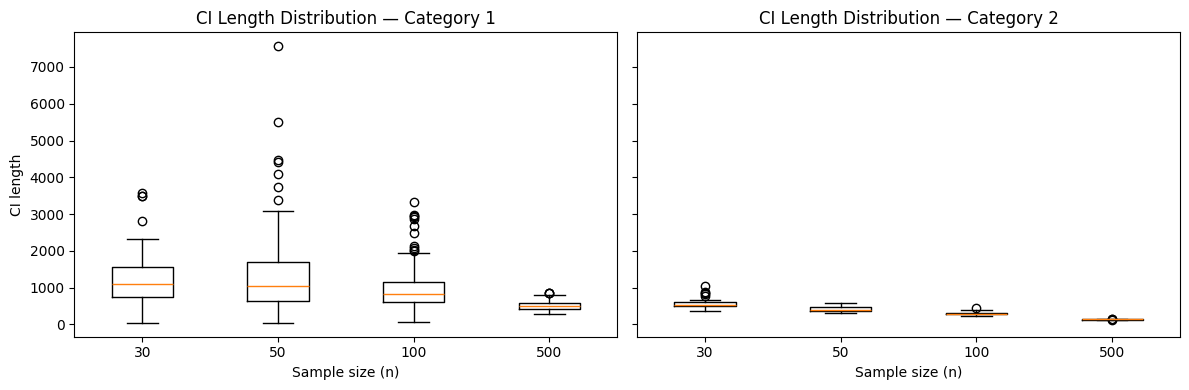

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Category 1
data_cat1 = [
    res_df.loc[res_df['n'] == n, 'CI_length_cat1']
    for n in sizes
]

axes[0].boxplot(data_cat1, labels=sizes)
axes[0].set_title("CI Length Distribution — Category 1")
axes[0].set_xlabel("Sample size (n)")
axes[0].set_ylabel("CI length")

# Category 2
data_cat2 = [
    res_df.loc[res_df['n'] == n, 'CI_length_cat2']
    for n in sizes
]

axes[1].boxplot(data_cat2, labels=sizes)
axes[1].set_title("CI Length Distribution — Category 2")
axes[1].set_xlabel("Sample size (n)")

plt.tight_layout()
plt.show()


   '


   '


   '


   

####  **Conclusion**

Repeating the sampling process 100 times for each sample size reveals clear patterns.

As the sample size increases, the distribution of confidence interval lengths becomes
more concentrated and shifts toward smaller values, indicating increased precision.

Similarly, the p-values of the Wald test become more stable and also decrease for larger samples, while
small samples exhibit high variability due to random sampling effects.

Finally, the results shows that larger samples lead to more
reliable conclusions, both when estimating parameters and when testing hypotheses.